# Baseline de popularidade

## Importando bibliotecas e gerando o split de dados para as baselines

In [21]:
import pandas as pd
from sklearn.preprocessing import MinMaxScaler
from mlxtend.frequent_patterns import apriori, association_rules
from collections import defaultdict
import sys
import os
sys.path.append(os.path.abspath("../src"))
from data_processing import load_and_prepare_data, split_train_validation


df = load_and_prepare_data("../data/processed/online_retail_clean.parquet")

#SPLIT DE DADOS
# ===============================================
train_df, validation_df = split_train_validation(df)

## remove cold users e cold items (<5 interações) da base de treino
train_user_counts = train_df['CustomerID'].value_counts()
cold_users = train_user_counts[train_user_counts < 5].index
train_item_counts = train_df['StockCode'].value_counts()
cold_items = train_item_counts[train_item_counts < 5].index
train_df = train_df[~train_df['StockCode'].isin(cold_items)]
train_df = train_df[~train_df['CustomerID'].isin(cold_users)]

# ===============================================
train_user_items = (train_df.drop_duplicates(['CustomerID','InvoiceNo','StockCode'])
                    .groupby('CustomerID')['StockCode'].apply(set).to_dict())

validation_user_items = (validation_df.drop_duplicates(['CustomerID','InvoiceNo','StockCode'])
                         .groupby('CustomerID')['StockCode'].apply(set).to_dict())

validation_users = list(validation_user_items.keys())


In [22]:
# 1) tabela base por item
itens_popularity = (
    train_df.groupby("StockCode")
      .agg(
          unique_users=("CustomerID", "nunique"),         # clientes distintos
          num_transactions=("InvoiceNo", "nunique"),      # faturas distintas
      )
)

# 2) descrição mais frequente por StockCode (modo)
desc_por_item = (
    train_df.groupby(["StockCode", "Description"])
      .size()
      .reset_index(name="freq")
      .sort_values(["StockCode", "freq"], ascending=[True, False])
      .drop_duplicates(subset="StockCode")           
      .set_index("StockCode")["Description"]
)

# 3) junta a descrição à tabela base
itens_popularity = itens_popularity.join(desc_por_item, how="left")


scaler = MinMaxScaler()
scaled = scaler.fit_transform(itens_popularity[["num_transactions","unique_users"]])
alpha = 0.5
itens_popularity["pop_score"] = alpha*scaled[:,0] + (1-alpha)*scaled[:,1]  # média ponderada

# 4) organiza colunas
itens_popularity = (
    itens_popularity
      .reset_index()
      .rename(columns={
          "StockCode": "stock_code",
          "Description": "description",
          "unique_users": "unique_users",
          "num_transactions": "num_transactions",
          "pop_score": "pop_score"
      })[["stock_code", "description", "unique_users", "num_transactions", "pop_score"]]
        .sort_values("pop_score", ascending=False)
)

# 5) exemplo: Top 10 por nº de faturas
print(itens_popularity.head(10))

top_popular_items = itens_popularity["stock_code"].tolist()

     stock_code                         description  unique_users  \
2892     85123A  WHITE HANGING HEART T-LIGHT HOLDER           635   
1187      22423            REGENCY CAKESTAND 3 TIER           658   
2879     85099B             JUMBO BAG RED RETROSPOT           489   
2390      47566                       PARTY BUNTING           548   
2741      84879       ASSORTED COLOUR BIRD ORNAMENT           492   
131       20725             LUNCH BAG RED RETROSPOT           451   
364       21212     PACK OF 72 RETROSPOT CAKE CASES           503   
1469      22720    SET OF 3 CAKE TINS PANTRY DESIGN           474   
2007      23298                      SPOTTY BUNTING           447   
1220      22457      NATURAL SLATE HEART CHALKBOARD           447   

      num_transactions  pop_score  
2892              1569   0.982470  
1187              1350   0.930077  
2879              1322   0.792326  
2390              1145   0.780782  
2741              1042   0.705213  
131               1120  

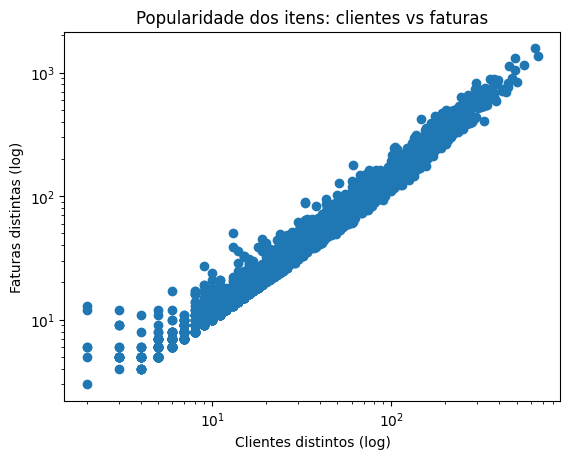

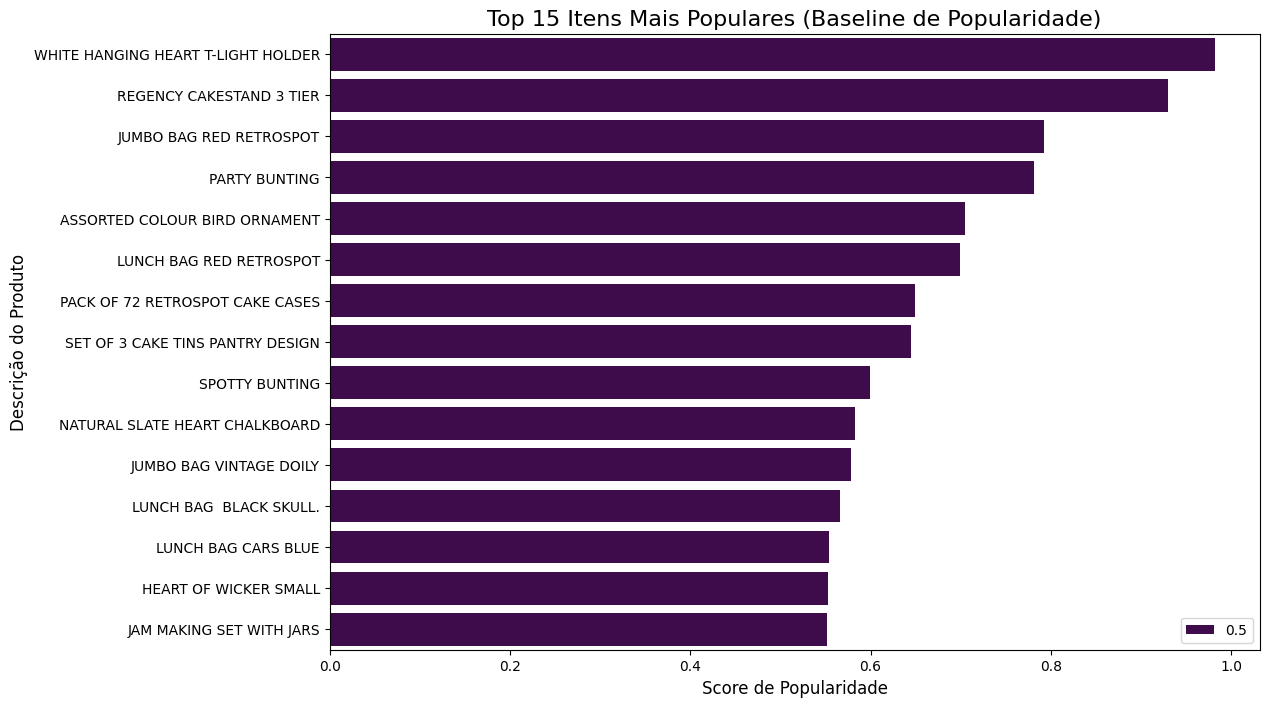

In [23]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.scatter(itens_popularity.unique_users, itens_popularity.num_transactions)
plt.xscale('log')
plt.yscale('log')
plt.xlabel("Clientes distintos (log)")
plt.ylabel("Faturas distintas (log)")
plt.title("Popularidade dos itens: clientes vs faturas")
plt.show()

top_n = 15
top_items = itens_popularity.sort_values('pop_score', ascending=False).head(top_n)
plt.figure(figsize=(12, 8))
sns.barplot(x=top_items['pop_score'], y=top_items['description'], palette='viridis', hue=0.5)
plt.title(f'Top {top_n} Itens Mais Populares (Baseline de Popularidade)', fontsize=16)
plt.xlabel('Score de Popularidade', fontsize=12)
plt.ylabel('Descrição do Produto', fontsize=12)
plt.show()

In [24]:
print(f"Total de usuários com histórico de treino: {len(train_user_items)}")
print(f"Total de usuários para avaliar (presentes na validação): {len(validation_users)}")

# Exemplo de como as estruturas se parecem:
# Pegar um usuário da lista de validação para exemplificar
if validation_users:
    example_user_id = validation_users[1]
    print(f"\n--- Exemplo para o Usuário ID: {example_user_id} ---")
    
    # Itens no treino (pode ser um conjunto vazio se o usuário for novo na validação)
    items_in_train = train_user_items.get(example_user_id, set())
    print(f"Itens comprados no treino ({len(items_in_train)}): {list(items_in_train)[:5]}...") 
    
    # Itens na validação
    items_in_validation = validation_user_items.get(example_user_id, [])
    print(f"Itens comprados na validação ({len(items_in_validation)}): {items_in_validation}")
else:
    print("\nNenhum usuário encontrado na validação para exibir exemplo.")


Total de usuários com histórico de treino: 2703
Total de usuários para avaliar (presentes na validação): 4334

--- Exemplo para o Usuário ID: 12347 ---
Itens comprados no treino (100): ['23420', '23147', '22774', '84992', '22992']...
Itens comprados na validação (11): {'23552', '23497', '23084', '84625A', '23271', '23508', '21265', '23506', '20719', '21064', '21731'}


In [25]:
def recommend_popular_items(u, K, exclude):
    recommendations = [item for item in top_popular_items if item not in exclude]
    return recommendations[:K]

# Baseline item-item knn

In [26]:
import numpy as np
from scipy.sparse import csr_matrix
from sklearn.preprocessing import normalize
from data_processing import create_mappings

# 1. Mapeamento de IDs para Índices da Matriz
user_map, item_map, inverse_user_map, inverse_item_map = create_mappings(train_df)

user_indices = train_df['CustomerID'].map(user_map)
item_indices = train_df['StockCode'].map(item_map)

# 3. Criar a matriz esparsa
purchase_indicators = np.ones(len(train_df))
num_users = len(user_map)
num_items = len(item_map)

# Matriz esparsa de interações usuário-item
user_item_matrix = csr_matrix(
    (purchase_indicators, (user_indices, item_indices)),
    shape=(num_users, num_items)
)


# --- Verificação Final ---
print("\nMatriz de interação criada com sucesso!")
print(f"Dimensões da matriz: {user_item_matrix.shape}")
print(f"Número de usuários: {num_users}")
print(f"Número de itens: {num_items}")

# Esparsidade da matriz
sparsity = 1.0 - (user_item_matrix.nnz / (num_users * num_items))
print(f"Esparsidade da matriz: {sparsity:.9f} ({sparsity*100:.7f}%)")

# Exemplo de compras de um usuário
print("\nExemplo de linha da matriz (usuário de índice 0):")
print(user_item_matrix[0])


Matriz de interação criada com sucesso!
Dimensões da matriz: (2703, 3049)
Número de usuários: 2703
Número de itens: 3049
Esparsidade da matriz: 0.976480829 (97.6480829%)

Exemplo de linha da matriz (usuário de índice 0):
<Compressed Sparse Row sparse matrix of dtype 'float64'
	with 21 stored elements and shape (1, 3049)>
  Coords	Values
  (0, 0)	17.0
  (0, 1)	17.0
  (0, 2)	15.0
  (0, 3)	17.0
  (0, 4)	17.0
  (0, 5)	16.0
  (0, 6)	17.0
  (0, 7)	16.0
  (0, 8)	16.0
  (0, 45)	7.0
  (0, 46)	15.0
  (0, 47)	14.0
  (0, 48)	15.0
  (0, 49)	15.0
  (0, 50)	15.0
  (0, 51)	14.0
  (0, 52)	15.0
  (0, 53)	15.0
  (0, 77)	10.0
  (0, 99)	4.0
  (0, 185)	8.0


In [27]:
from sklearn.metrics.pairwise import cosine_similarity

item_user_matrix = user_item_matrix.T
item_similarity_matrix = cosine_similarity(item_user_matrix)

item_id = 25  # Exemplo: índice do item para o qual queremos encontrar similares

if num_items != item_id:
    similarities_for_item_0 = item_similarity_matrix[item_id]
    # Encontrar os índices dos top 10 mais similares (excluindo ele mesmo)
    # argsort ordena do menor para o maior, então pegamos do final
    most_similar_indices = np.argsort(similarities_for_item_0)[-16:-1]
    
    # Traduzir de volta para StockCodes
    original_item_id = inverse_item_map[item_id]
    similar_item_ids = [inverse_item_map[i] for i in most_similar_indices]

    print(f"\nExemplo: Itens mais similares ao item '{original_item_id}'- '{df[df['StockCode'] == original_item_id]['Description'].values[0]}':")

    for similar_item_id in similar_item_ids:
        description = df[df['StockCode'] == similar_item_id]['Description'].values[0]
        print(f"- {similar_item_id}: {description}")


Exemplo: Itens mais similares ao item '22728'- 'ALARM CLOCK BAKELIKE PINK':
- 23298: SPOTTY BUNTING
- 23238: SET OF 4 KNICK KNACK TINS LONDON
- 22993: SET OF 4 PANTRY JELLY MOULDS
- 23241: TREASURE TIN GYMKHANA DESIGN
- 22720: SET OF 3 CAKE TINS PANTRY DESIGN
- 23245: SET OF 3 REGENCY CAKE TINS
- 23240: SET OF 4 KNICK KNACK TINS DOILEY
- 22193: RED DINER WALL CLOCK
- 22191: IVORY DINER WALL CLOCK
- 22192: BLUE DINER WALL CLOCK
- 22725: ALARM CLOCK BAKELIKE CHOCOLATE
- 22730: ALARM CLOCK BAKELIKE IVORY
- 22729: ALARM CLOCK BAKELIKE ORANGE
- 22726: ALARM CLOCK BAKELIKE GREEN
- 22727: ALARM CLOCK BAKELIKE RED


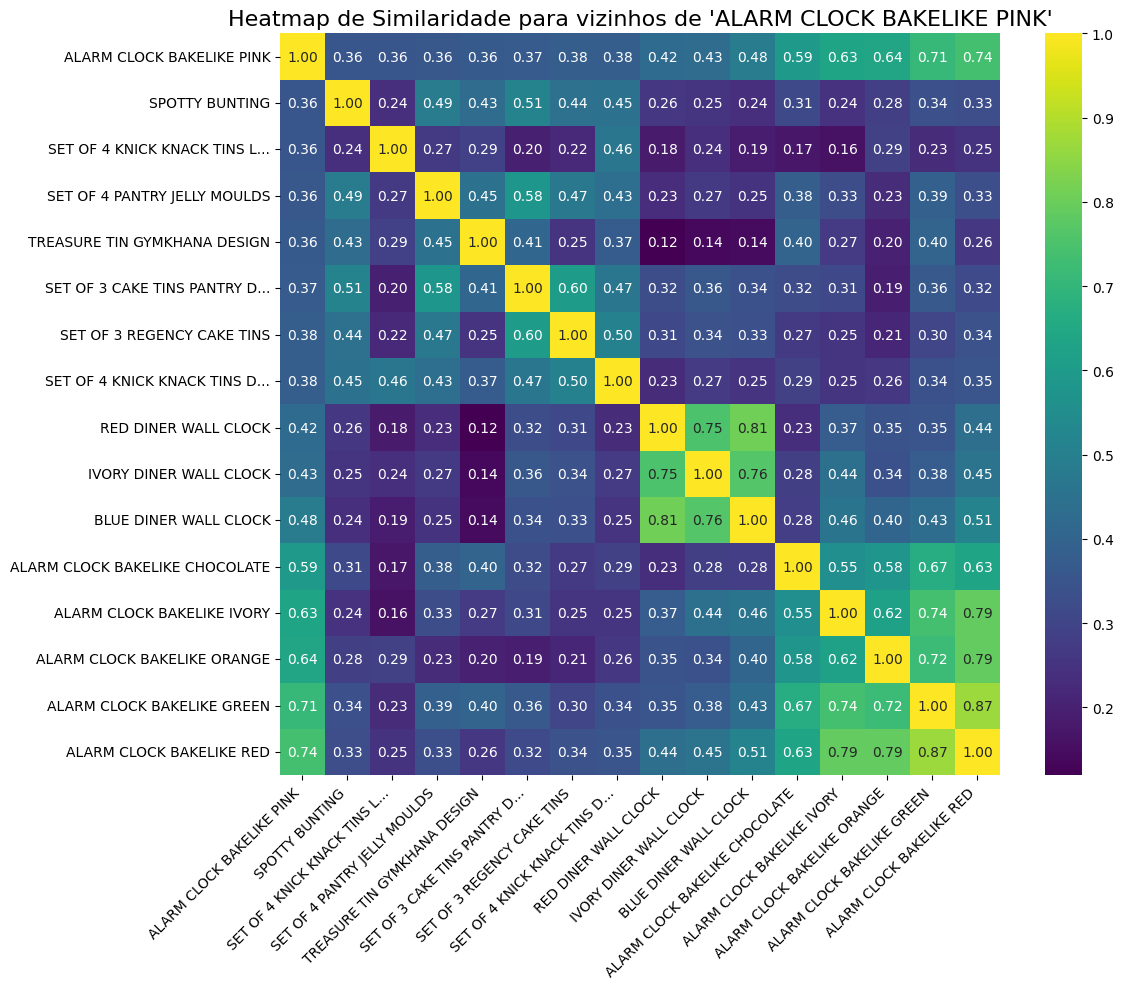

In [28]:
all_indices = np.concatenate([[item_id], most_similar_indices])

# 2. "Recortar" a submatriz de similaridade para apenas esses itens
#    Usamos np.ix_ para fatiar elegantemente as linhas e colunas
similarity_subset = item_similarity_matrix[np.ix_(all_indices, all_indices)]

# 3. Preparar os rótulos (descrições dos produtos) para o gráfico
#    Vamos encurtar descrições muito longas para caberem no gráfico
def shorten_label(desc, max_len=30):
    if len(desc) > max_len:
        return desc[:max_len-3] + "..."
    return desc

# Buscando as descrições originais e encurtando-as
descriptions = []
for idx in all_indices:
    stock_code = inverse_item_map[idx]
    # Usamos .iloc[0] para pegar o primeiro resultado caso haja descrições duplicadas
    desc = df[df['StockCode'] == stock_code]['Description'].iloc[0]
    descriptions.append(shorten_label(desc))

# 4. Plotar o Heatmap 🌡️
plt.figure(figsize=(12, 10))
sns.heatmap(
    similarity_subset,
    xticklabels=descriptions,
    yticklabels=descriptions,
    cmap='viridis', 
    annot=True,     
    fmt=".2f"       
)
plt.title(f"Heatmap de Similaridade para vizinhos de '{descriptions[0]}'", fontsize=16)
plt.xticks(rotation=45, ha='right') 
plt.yticks(rotation=0)
plt.tight_layout()
plt.show()

In [29]:
def recommend_knn_items(user_id, K, exclude):
    user_idx = user_map[user_id]
    # Itens que o usuário já comprou no treino
    user_items = train_user_items.get(user_id, set())
    item_indices_user = [item_map[item] for item in user_items if item in item_map]

    # Soma as similaridades dos itens do usuário com todos os itens
    if item_indices_user:
        scores = item_similarity_matrix[item_indices_user].sum(axis=0)
    else:
        scores = np.zeros(item_similarity_matrix.shape[0])

    # Exclui itens já comprados
    for item in exclude:
        if item in item_map:
            item_idx = item_map[item]
            scores[item_idx] = -np.inf  # Define uma pontuação baixa para itens já comprados

    # Pega os índices dos top K itens
    top_k_indices = np.argsort(scores)[-K:][::-1]

    # Traduz de volta para StockCodes
    recommended_items = [inverse_item_map[i] for i in top_k_indices]
    return recommended_items

## Baseline Apriori

In [30]:
print("--- [PASSO 1] Preparando Matriz para Apriori ---")
basket = (train_df.groupby(['InvoiceNo', 'StockCode'])['Quantity']
              .sum().unstack().reset_index().fillna(0)
              .set_index('InvoiceNo'))
    
# 3. Converter para Booleano (True/False)
# Isso economiza memória e é o formato nativo do apriori
basket = basket.apply(lambda x: x > 0)

print(f"Matriz Cesta Criada. Dimensões: {basket.shape}")
print("Exemplo: (Linhas=Faturas, Colunas=Itens)")

--- [PASSO 1] Preparando Matriz para Apriori ---
Matriz Cesta Criada. Dimensões: (13893, 3049)
Exemplo: (Linhas=Faturas, Colunas=Itens)


In [31]:
min_support=0.01
min_confidence=0.1
print(f"\n--- [PASSO 2] Rodando Apriori (min_support={min_support}) ---")

frequent_itemsets = apriori(basket, min_support=min_support, use_colnames=True)
    
if frequent_itemsets.empty:
    print("AVISO: Nenhum itemset frequente encontrado! Tente diminuir o min_support.")

    
print(f"Itemsets frequentes encontrados: {len(frequent_itemsets)}")

# Gerar Regras
print(f"Gerando regras com min_confidence={min_confidence}...")
rules = association_rules(frequent_itemsets, metric="confidence", min_threshold=min_confidence)

print(f"Regras geradas: {len(rules)}")
if not rules.empty:
    print("Top Regras por Confiança:")
    print(rules.sort_values('confidence', ascending=False)[['antecedents', 'consequents', 'confidence']].head())


--- [PASSO 2] Rodando Apriori (min_support=0.01) ---
Itemsets frequentes encontrados: 1214
Gerando regras com min_confidence=0.1...
Regras geradas: 1875
Top Regras por Confiança:
         antecedents consequents  confidence
1611  (23170, 23172)     (23171)    0.950617
651          (22916)     (22917)    0.936306
658          (22918)     (22917)    0.929936
664          (22918)     (22919)    0.923567
1610  (23171, 23172)     (23170)    0.922156


In [32]:
def recommend_apriori(rules, train_df, validation_users, top_k=10):
    
    # Otimização: Mapa de Regras
    rules_map = defaultdict(list)
    for _, row in rules.iterrows():
        ant = tuple(sorted(list(row['antecedents'])))
        con = list(row['consequents'])[0] 
        conf = row['confidence']
        rules_map[ant].append((con, conf))
        
    # Histórico dos usuários no treino
    user_histories = train_df.groupby('CustomerID')['StockCode'].apply(set).to_dict()
    
    apriori_recs = {}
    total_users = len(validation_users)
    
    for idx, user_id in enumerate(validation_users):
        if idx % 500 == 0:
            print(f"Processando usuário {idx}/{total_users}...")
            
        history = user_histories.get(user_id, set())
        
        candidates = defaultdict(float)
        
        # Lógica de Recomendação
        for ant, rule_list in rules_map.items():
            if set(ant).issubset(history): # Se o usuário comprou o antecedente...
                for item, conf in rule_list:
                    # Permite recompra (B2B) - Não filtramos itens já vistos
                    candidates[item] += conf 
        
        # Top K
        sorted_candidates = sorted(candidates.items(), key=lambda x: x[1], reverse=True)
        top_items = [item for item, score in sorted_candidates[:top_k]]
        apriori_recs[user_id] = top_items
        
    return apriori_recs

# Resultados das baselines
## Baseline de popularidade

In [33]:
from evaluation import evaluate_recommender, get_results_df, compare_models

K_values = [5, 10, 20]
all_results = []
common_validation_users = [u for u in validation_users if u in user_map]
empty_exclude_dict = {u: set() for u in common_validation_users}

for k in K_values:
    print(f"\nCalculando métricas para K={k}...")
    
    # Chama a sua função de avaliação genérica
    results_k = evaluate_recommender(
        users=common_validation_users,
        recommend_fn=recommend_popular_items,
        truth_dict=validation_user_items,
        exclude_seen_dict=empty_exclude_dict,
        k=k
    )

    row = {
        'K': k,
        'users_eval': results_k['users_eval'],
        'Precision': results_k[f'P@{k}'], # Pega o valor da chave dinâmica 'P@k'
        'Recall': results_k[f'R@{k}'],    # Pega o valor da chave dinâmica 'R@k'
        'NDCG': results_k[f'NDCG@{k}']   # Pega o valor da chave dinâmica 'NDCG@k'
    }
    all_results.append(row)
    print(f"Resultados para K={k}: {results_k}")


Calculando métricas para K=5...
Resultados para K=5: {'users_eval': 2703, 'P@5': 0.07036625971143175, 'R@5': 0.024741962174240295, 'NDCG@5': 0.07589325451155267}

Calculando métricas para K=10...
Resultados para K=10: {'users_eval': 2703, 'P@10': 0.05760266370699223, 'R@10': 0.03627898544335961, 'NDCG@10': 0.06873218894216455}

Calculando métricas para K=20...
Resultados para K=20: {'users_eval': 2703, 'P@20': 0.04972253052164262, 'R@20': 0.05557914938235578, 'NDCG@20': 0.06843708415222134}


## Baseline item-item KNN

In [34]:
all_results_knn = []

for k in K_values:
    print(f"\nCalculando métricas para K={k}...")
    
    results_k = evaluate_recommender(
        users=common_validation_users,
        recommend_fn=recommend_knn_items,
        truth_dict=validation_user_items,
        exclude_seen_dict=empty_exclude_dict,
        k=k
    )

    row = {
        'K': k,
        'users_eval': results_k['users_eval'],
        'Precision': results_k[f'P@{k}'], # Pega o valor da chave dinâmica 'P@k'
        'Recall': results_k[f'R@{k}'],    # Pega o valor da chave dinâmica 'R@k'
        'NDCG': results_k[f'NDCG@{k}']   # Pega o valor da chave dinâmica 'NDCG@k'
    }
    all_results_knn.append(row)
    print(f"Resultados para K={k}: {results_k}")


Calculando métricas para K=5...
Resultados para K=5: {'users_eval': 2703, 'P@5': 0.1360710321864595, 'R@5': 0.06095095139463144, 'NDCG@5': 0.1502471324731744}

Calculando métricas para K=10...
Resultados para K=10: {'users_eval': 2703, 'P@10': 0.11664816870144284, 'R@10': 0.09530925634664053, 'NDCG@10': 0.1452677441184414}

Calculando métricas para K=20...
Resultados para K=20: {'users_eval': 2703, 'P@20': 0.09247132815390308, 'R@20': 0.13744555022877503, 'NDCG@20': 0.14597412524170797}


## Baseline Apriori

In [42]:
K_values = [5, 10, 20]
max_k = max(K_values) 

# 2. GERAÇÃO: Rodando o Apriori UMA VEZ para o maior K
# Isso gera o dicionário {user_id: [item1, item2, ..., item20]}
print(f"Gerando pool de recomendações Apriori (Top-{max_k})...")
apriori_recs_pool = recommend_apriori(rules, train_df, common_validation_users, top_k=max_k)

# 3. ADAPTADOR: Crie uma função que o 'evaluate_recommender' consiga chamar
# Essa função finge ser um modelo, mas só olha no dicionário que já criamos
def apriori_lookup_fn(user_id, K, exclude):
    # Busca a lista completa do usuário (ou lista vazia se não tiver)
    full_list = apriori_recs_pool.get(user_id, [])
    # Retorna apenas os primeiros k itens
    return full_list[:K]

# 4. LOOP DE AVALIAÇÃO 
all_results_apriori = []

print("\n--- Iniciando Avaliação do Apriori ---")
for k in K_values:
    print(f"\nCalculando métricas Apriori para K={k}...")
    
    results_k = evaluate_recommender(
        users=common_validation_users,
        recommend_fn=apriori_lookup_fn, 
        truth_dict=validation_user_items,
        exclude_seen_dict=empty_exclude_dict, # Mantemos vazio pois é B2B (recompra)
        k=k
    )

    row = {
        'K': k,
        'users_eval': results_k['users_eval'],
        'Precision': results_k[f'P@{k}'],
        'Recall': results_k[f'R@{k}'],
        'NDCG': results_k[f'NDCG@{k}']
    }
    all_results_apriori.append(row)
    print(f"Resultados Apriori K={k}: NDCG={row['NDCG']:.4f}, Recall={row['Recall']:.4f}")

df_results_apriori = pd.DataFrame(all_results_apriori)
print("\nResumo Final Apriori:")
print(df_results_apriori)

Gerando pool de recomendações Apriori (Top-20)...
Processando usuário 0/2703...
Processando usuário 500/2703...
Processando usuário 1000/2703...
Processando usuário 1500/2703...
Processando usuário 2000/2703...
Processando usuário 2500/2703...

--- Iniciando Avaliação do Apriori ---

Calculando métricas Apriori para K=5...
Resultados Apriori K=5: NDCG=0.1316, Recall=0.0418

Calculando métricas Apriori para K=10...
Resultados Apriori K=10: NDCG=0.1239, Recall=0.0679

Calculando métricas Apriori para K=20...
Resultados Apriori K=20: NDCG=0.1228, Recall=0.1033

Resumo Final Apriori:
    K  users_eval  Precision    Recall      NDCG
0   5        2703   0.125342  0.041833  0.131569
1  10        2703   0.106955  0.067939  0.123906
2  20        2703   0.087421  0.103252  0.122834


In [43]:
df_knn = get_results_df(all_results_knn, "KNN")
df_pop = get_results_df(all_results, "Popularidade")
df_apriori = get_results_df(all_results_apriori, "Apriori")

print("\n\n=========== Resultados Finais - Popularidade: ===============")
print(df_pop.set_index('K'))
print("\n\n================ Resultados Finais - KNN: ===================")
print(df_knn.set_index('K'))
print("\n\n=========== Resultados Finais - Apriori: ===============")
print(df_results_apriori.set_index('K'))




=========== Resultados Finais - Popularidade: ===============
    users_eval  Precision    Recall      NDCG         Model
K                                                          
5         2703   0.070366  0.024742  0.075893  Popularidade
10        2703   0.057603  0.036279  0.068732  Popularidade
20        2703   0.049723  0.055579  0.068437  Popularidade


================ Resultados Finais - KNN: ===================
    users_eval  Precision    Recall      NDCG Model
K                                                  
5         2703   0.136071  0.060951  0.150247   KNN
10        2703   0.116648  0.095309  0.145268   KNN
20        2703   0.092471  0.137446  0.145974   KNN


=========== Resultados Finais - Apriori: ===============
    users_eval  Precision    Recall      NDCG
K                                            
5         2703   0.125342  0.041833  0.131569
10        2703   0.106955  0.067939  0.123906
20        2703   0.087421  0.103252  0.122834


### Comparação das baselines

In [ ]:
compare_models(df_knn, df_pop, "KNN", "Popularidade")

--- Comparação: KNN vs. Popularidade ---

K=5

- Precision@5: 0.1361 vs 0.0704 → +93%
- Recall@5: 0.0610 vs 0.0247 → +146%
- NDCG@5: 0.1502 vs 0.0759 → +98%
--------------------
K=10

- Precision@10: 0.1166 vs 0.0576 → +103%
- Recall@10: 0.0953 vs 0.0363 → +163%
- NDCG@10: 0.1453 vs 0.0687 → +111%
--------------------
K=20

- Precision@20: 0.0925 vs 0.0497 → +86%
- Recall@20: 0.1374 vs 0.0556 → +147%
- NDCG@20: 0.1460 vs 0.0684 → +113%
--------------------


In [ ]:
#exportando df_knn e df_pop
df_knn.to_parquet("../data/processed/df_knn.parquet", index=False)
df_pop.to_parquet("../data/processed/df_pop.parquet", index=False)